In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df=pd.read_csv("final_dataset.csv")

In [39]:
df.head()

,time,temperature,humidity,pm10,pm2_5,no2,co,aqi,traffic_index,hour,day,month,day_of_week,is_weekend
0,2025-10-01 00:00:00,28.80,71.78876,79.2,41.6,42.7,1012.0,120.156250,0.13,0,1,10,2,0
1,2025-10-01 01:00:00,28.45,72.82045,70.8,41.3,43.3,805.0,118.854164,0.13,1,1,10,2,0
2,2025-10-01 02:00:00,28.00,74.07781,66.1,41.2,44.0,640.0,117.770830,0.12,2,1,10,2,0
3,2025-10-01 03:00:00,27.45,76.49700,62.4,41.0,45.6,557.0,117.249990,0.09,3,1,10,2,0
4,2025-10-01 04:00:00,27.05,77.83946,62.6,41.9,47.3,515.0,117.552080,0.09,4,1,10,2,0


In [40]:
df["aqi"].max()

np.float64(290.32083)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           2208 non-null   object 
 1   temperature    2208 non-null   float64
 2   humidity       2208 non-null   float64
 3   pm10           2208 non-null   float64
 4   pm2_5          2208 non-null   float64
 5   no2            2208 non-null   float64
 6   co             2208 non-null   float64
 7   aqi            2208 non-null   float64
 8   traffic_index  2208 non-null   float64
 9   hour           2208 non-null   int64  
 10  day            2208 non-null   int64  
 11  month          2208 non-null   int64  
 12  day_of_week    2208 non-null   int64  
 13  is_weekend     2208 non-null   int64  
dtypes: float64(8), int64(5), object(1)
memory usage: 241.6+ KB


In [42]:
df.describe()

,temperature,humidity,pm10,pm2_5,no2,co,aqi,traffic_index,hour,day,month,day_of_week,is_weekend
count,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000
mean,20.730027,61.269154,137.057473,99.360100,44.259058,1185.878170,173.436445,0.429755,11.500000,15.836957,11.000000,2.989130,0.282609
std,5.857472,19.279096,71.383657,56.392319,30.515023,619.675704,34.089571,0.293450,6.923755,8.856232,0.821108,1.992253,0.450370
min,8.600000,21.749865,14.000000,12.100000,3.200000,232.000000,80.514180,0.050000,0.000000,1.000000,10.000000,0.000000,0.000000
25%,15.850000,46.764986,82.200000,60.300000,20.975000,721.750000,155.108002,0.190000,5.750000,8.000000,10.000000,1.000000,0.000000
50%,21.000000,61.285389,122.700000,84.300000,36.350000,1031.000000,167.770840,0.360000,11.500000,16.000000,11.000000,3.000000,0.000000
75%,25.000000,75.358080,177.400000,120.600000,59.800000,1518.250000,182.857462,0.560000,17.250000,23.250000,12.000000,5.000000,1.000000
max,34.600000,99.670815,456.300000,333.400000,176.200000,3878.000000,290.320830,1.000000,23.000000,31.000000,12.000000,6.000000,1.000000


In [43]:
df.columns

Index(['time', 'temperature', 'humidity', 'pm10', 'pm2_5', 'no2', 'co', 'aqi',
       'traffic_index', 'hour', 'day', 'month', 'day_of_week', 'is_weekend'],
      dtype='object')

In [44]:
df.isnull().sum()

time             0
temperature      0
humidity         0
pm10             0
pm2_5            0
no2              0
co               0
aqi              0
traffic_index    0
hour             0
day              0
month            0
day_of_week      0
is_weekend       0
dtype: int64

In [45]:
# New Column for Weekend or Weekday
df["day_type"]= df["is_weekend"].map({0: "Weekday", 1: "Weekend"})
df.head()

,time,temperature,humidity,pm10,pm2_5,no2,co,aqi,traffic_index,hour,day,month,day_of_week,is_weekend,day_type
0,2025-10-01 00:00:00,28.80,71.78876,79.2,41.6,42.7,1012.0,120.156250,0.13,0,1,10,2,0,Weekday
1,2025-10-01 01:00:00,28.45,72.82045,70.8,41.3,43.3,805.0,118.854164,0.13,1,1,10,2,0,Weekday
2,2025-10-01 02:00:00,28.00,74.07781,66.1,41.2,44.0,640.0,117.770830,0.12,2,1,10,2,0,Weekday
3,2025-10-01 03:00:00,27.45,76.49700,62.4,41.0,45.6,557.0,117.249990,0.09,3,1,10,2,0,Weekday
4,2025-10-01 04:00:00,27.05,77.83946,62.6,41.9,47.3,515.0,117.552080,0.09,4,1,10,2,0,Weekday


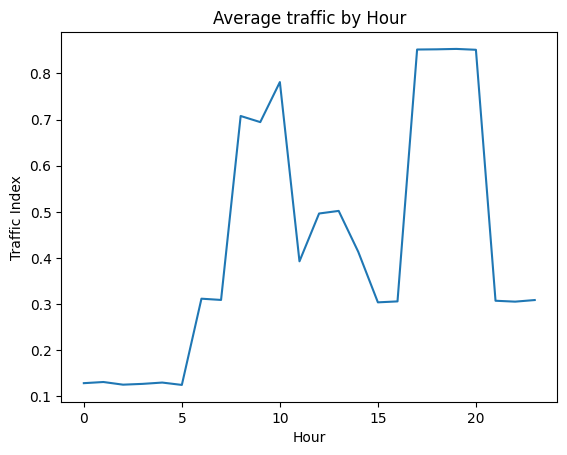

<Figure size 640x480 with 0 Axes>

In [49]:
#PEAK TRAFFIC HOURS
hourly_traffic= df.groupby("hour")["traffic_index"].mean()

plt.figure()
hourly_traffic.plot()
plt.title("Average traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic Index")
plt.show()
plt.savefig("charts/avg_congestion_by_hour.png")

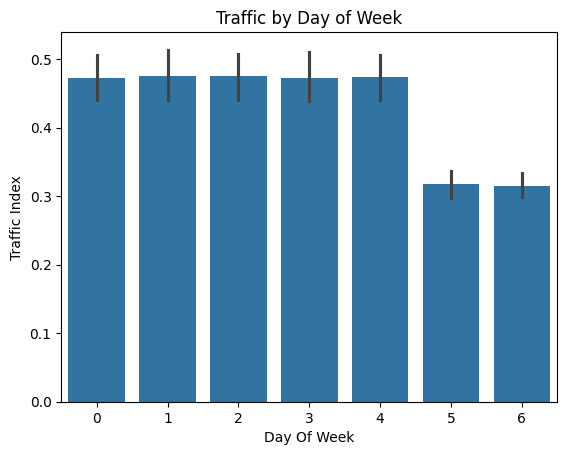

<Figure size 640x480 with 0 Axes>

In [50]:
# Day-wise Traffic Pattern

sns.barplot(x="day_of_week", y="traffic_index", data=df)
plt.title("Traffic by Day of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Traffic Index")
plt.show()
plt.savefig("charts/traffic_by_day_of_week")

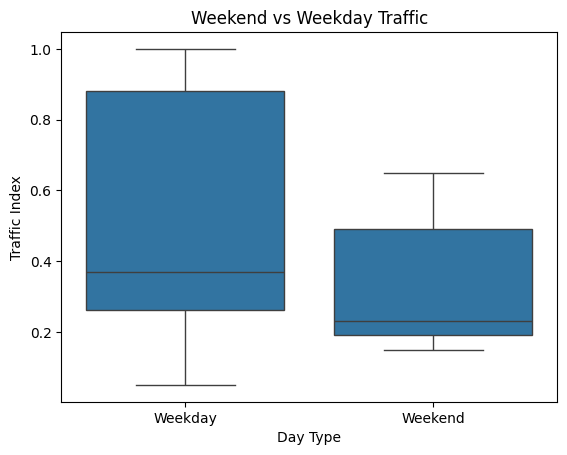

<Figure size 640x480 with 0 Axes>

In [51]:
# Weekend vs Weekday
sns.boxplot(x="day_type", y="traffic_index", data=df)
plt.title("Weekend vs Weekday Traffic")
plt.xlabel("Day Type")
plt.ylabel("Traffic Index")
plt.show()
plt.savefig("charts/weekend_vs_weekday.png")

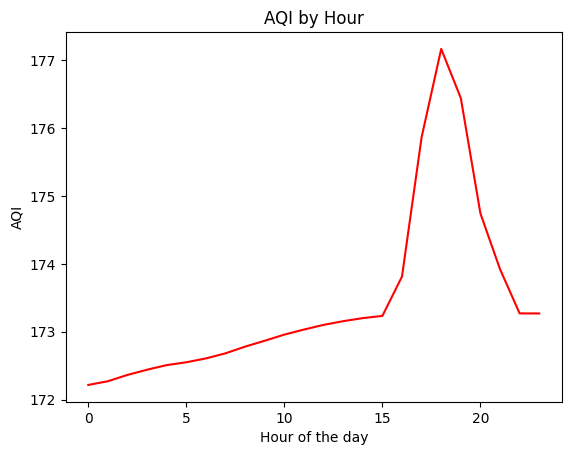

<Figure size 640x480 with 0 Axes>

In [52]:
# Pollution Trends (AQI vs Hour)
aqi_hour = df.groupby("hour")["aqi"].mean()

plt.figure()
aqi_hour.plot(color='red')
plt.title("AQI by Hour")
plt.xlabel("Hour of the day")
plt.ylabel("AQI")
plt.show()
plt.savefig("charts/aqi_by_hour.png")

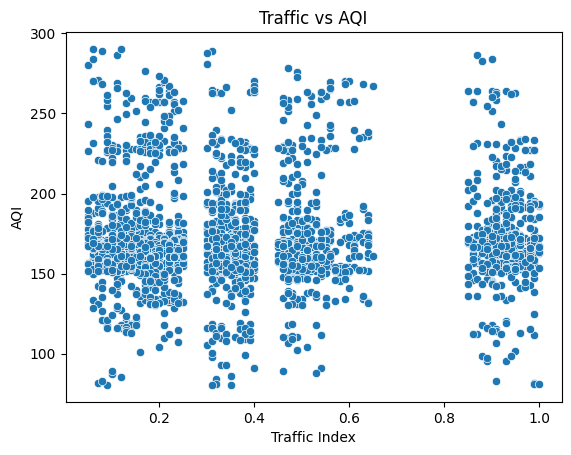

<Figure size 640x480 with 0 Axes>

In [53]:
# Traffic vs Pollution (MOST IMPORTANT)

sns.scatterplot(x="traffic_index", y="aqi", data=df)
plt.title("Traffic vs AQI")
plt.xlabel("Traffic Index")
plt.ylabel("AQI")
plt.show()
plt.savefig("charts/traffic_vs_aqi.png")

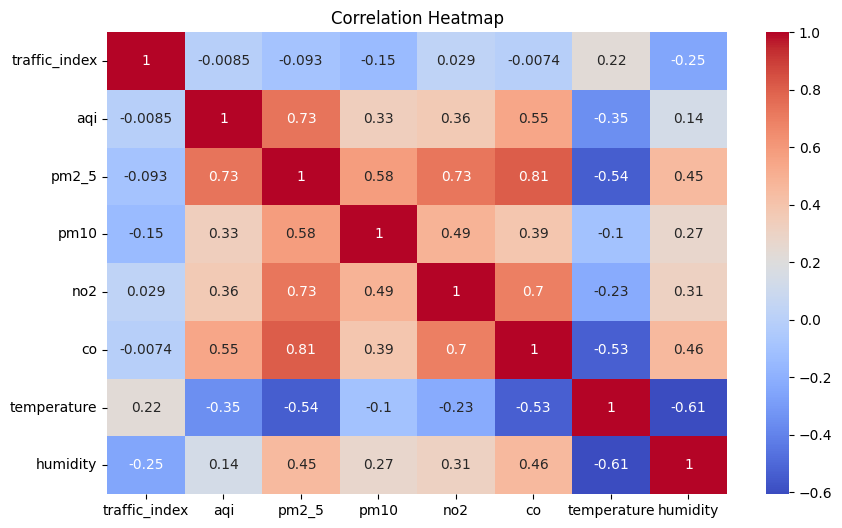

<Figure size 640x480 with 0 Axes>

In [54]:
# Correlation Heatmap 
corr = df[['traffic_index','aqi','pm2_5','pm10','no2','co','temperature','humidity']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
plt.savefig("charts/correlation_heatmap.png")

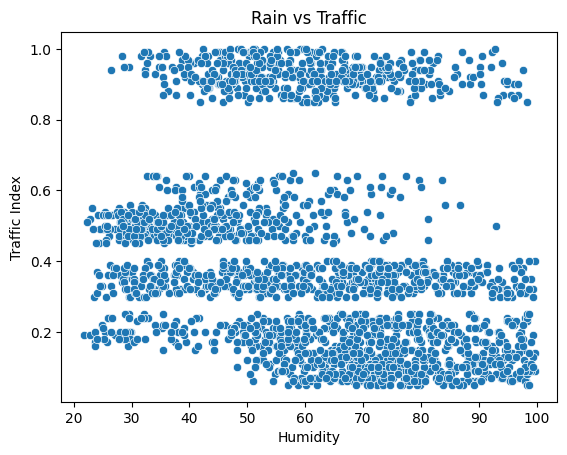

<Figure size 640x480 with 0 Axes>

In [55]:
# Weather Impact on Traffic
sns.scatterplot(x="humidity", y="traffic_index", data=df)
plt.title("Rain vs Traffic")
plt.xlabel("Humidity")
plt.ylabel("Traffic Index")
plt.show()
plt.savefig("charts/rain_vs_traffic.png")

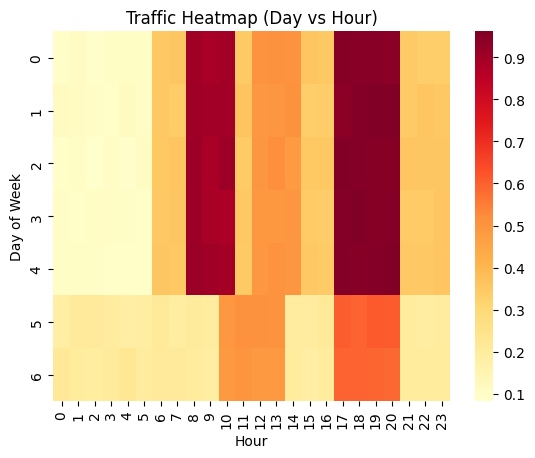

<Figure size 640x480 with 0 Axes>

In [56]:
# Heatmap (Hour vs Day)
pivot = df.pivot_table(values="traffic_index", index="day_of_week", columns="hour")

sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Traffic Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()
plt.savefig("charts/hour_vs_day_heatmap.png")

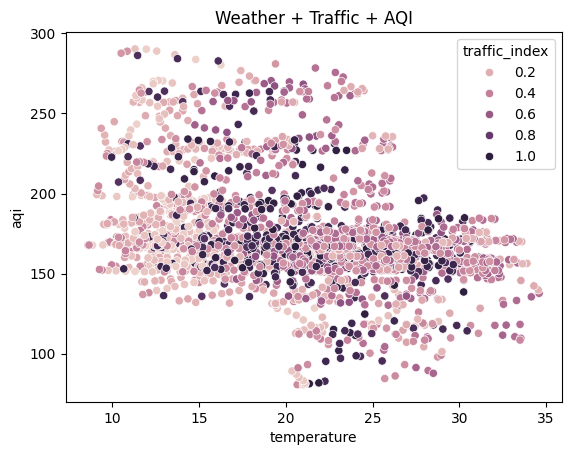

<Figure size 640x480 with 0 Axes>

In [57]:
#Combine Insight 

sns.scatterplot(x="temperature", y="aqi", hue="traffic_index", data=df)
plt.title("Weather + Traffic + AQI")
plt.show()
plt.savefig("charts/combined_insight_scatterplot.png")

In [59]:
df.columns

Index(['time', 'temperature', 'humidity', 'pm10', 'pm2_5', 'no2', 'co', 'aqi',
       'traffic_index', 'hour', 'day', 'month', 'day_of_week', 'is_weekend',
       'day_type', 'aqi_next'],
      dtype='object')

In [61]:
df.to_csv("urban_dataset.csv", index=False)